### Week 3 : Battery State of Charge (SOC) Prediction Using GRU

This project focuses on predicting the State of Charge (SOC) of a lithium-ion battery using a Gated Recurrent Unit (GRU) neural network. Battery SOC estimation is a critical component of Battery Management Systems (BMS) used in electric vehicles, energy storage systems, and portable electronics.

The objective of this work is to train a GRU model using battery measurements such as Voltage (V), Current (I), and Temperature (T) to predict the battery SOC. Since battery behavior is time-dependent, a recurrent neural network architecture is used to capture temporal patterns in the battery data.

### Problem Statement

Accurate estimation of battery State of Charge (SOC) is essential for ensuring battery safety, reliability, and efficient energy utilization. Traditional methods often struggle to capture the nonlinear and dynamic characteristics of battery behavior.

In this project, a GRU-based deep learning model is developed to learn temporal relationships between battery measurements and SOC values. The model uses historical battery observations to predict future SOC values.

#### Dataset Description

The battery dataset(CALCE) used in this project contains measurements collected during battery charge and discharge cycles.

Features Used
Voltage (V)
Current (I)
Temperature (T)
Target Variable
State of Charge (SOC)
Dataset Size
Rows: 6947
Columns: 19

The dataset contains additional battery parameters such as charge capacity, discharge capacity, energy measurements, impedance values, and cycle information.

#### WORKFLOW;


Battery Dataset
       -->
Data Preprocessing
       -->
Feature Selection
       -->
Normalization
       -->
Sliding Window Creation
       -->
GRU Model Training
       -->
SOC Prediction
       -->
Performance Evaluation
       -->
Model Saving

In [2]:
import pandas as pd

df = pd.read_csv("TBJDST_2550.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (6947, 19)


,Data_Point,Test_Time_s_,Step_Time_s_,Step_Index,Cycle_Index,I,V,ChargeCapacityAh,Discharge_CapacityAh,Charge_EnergyWh,Discharge_EnergyWh,dV_dt_V_s_,Internal_Resistance_Ohm_,Is_FC_Data,AC_Impedance_Ohm_,ACI_Phase_Angle_Deg_,T,SOC,QAccu
0,1439,14430,1.0000,6,1,0.00000,3.6494,2.0477,1.0002,7.8747,3.8096,0.014667,0,0,0,0,25,0.50000,0.000000
1,1440,14431,1.0157,7,1,-0.11073,3.6424,2.0477,1.0002,7.8747,3.8097,-0.001425,0,0,0,0,25,0.49999,-0.000031
2,1441,14432,2.0310,7,1,-0.11091,3.6431,2.0477,1.0003,7.8747,3.8098,-0.001295,0,0,0,0,25,0.49997,-0.000062
3,1442,14433,3.0314,7,1,-0.11109,3.6436,2.0477,1.0003,7.8747,3.8099,-0.001198,0,0,0,0,25,0.49996,-0.000092
4,1443,14434,4.0470,7,1,-0.11109,3.6442,2.0477,1.0003,7.8747,3.8100,-0.001068,0,0,0,0,25,0.49994,-0.000124


In [3]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Preprocessing
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# Evaluation Metrics
from sklearn.metrics import mean_absolute_error

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense

# Ignore Warnings
import warnings
warnings.filterwarnings('ignore')

### Exploratory Data Analysis (EDA)

Before training the GRU model, the dataset is inspected to understand the available features, data quality, and statistical characteristics. This step helps identify relevant variables and detect potential issues such as missing values.



In [4]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Dataset Shape: (6947, 19)

Column Names:
['Data_Point', 'Test_Time_s_', 'Step_Time_s_', 'Step_Index', 'Cycle_Index', 'I', 'V', 'ChargeCapacityAh', 'Discharge_CapacityAh', 'Charge_EnergyWh', 'Discharge_EnergyWh', 'dV_dt_V_s_', 'Internal_Resistance_Ohm_', 'Is_FC_Data', 'AC_Impedance_Ohm_', 'ACI_Phase_Angle_Deg_', 'T', 'SOC', 'QAccu']

Data Types:
Data_Point                    int64
Test_Time_s_                  int64
Step_Time_s_                float64
Step_Index                    int64
Cycle_Index                   int64
I                           float64
V                           float64
ChargeCapacityAh            float64
Discharge_CapacityAh        float64
Charge_EnergyWh             float64
Discharge_EnergyWh          float64
dV_dt_V_s_                  float64
Internal_Resistance_Ohm_      int64
Is_FC_Data                    int64
AC_Impedance_Ohm_             int64
ACI_Phase_Angle_Deg_          int64
T                             int64
SOC                         float64
QAccu

#### Dataset Overview

The dataset contains battery measurements collected during battery operation. The available features include voltage, current, temperature, capacity, energy, impedance, and SOC measurements.

Understanding the dataset structure is important before applying preprocessing and deep learning techniques.

In [5]:
df.isnull().sum()

Data_Point                  0
Test_Time_s_                0
Step_Time_s_                0
Step_Index                  0
Cycle_Index                 0
I                           0
V                           0
ChargeCapacityAh            0
Discharge_CapacityAh        0
Charge_EnergyWh             0
Discharge_EnergyWh          0
dV_dt_V_s_                  0
Internal_Resistance_Ohm_    0
Is_FC_Data                  0
AC_Impedance_Ohm_           0
ACI_Phase_Angle_Deg_        0
T                           0
SOC                         0
QAccu                       0
dtype: int64

No missing values were observed in the dataset. Therefore, no imputation or missing value treatment was required before model development.

In [6]:
df[['V','I','T','SOC']].describe()

,V,I,T,SOC
count,6947.000000,6947.000000,6947.0,6947.000000
mean,3.497459,-0.536021,25.0,0.250781
std,0.112970,0.519032,0.0,0.142138
min,2.499400,-1.667400,25.0,0.000000
25%,3.447900,-1.000200,25.0,0.123730
50%,3.521000,-0.277620,25.0,0.246280
75%,3.575400,-0.167260,25.0,0.373100
max,3.671600,0.444280,25.0,0.500000


#### Observations from Statistical Analysis
The dataset contains 6947 battery measurements with no reduction in sample size for the selected variables.

The battery voltage ranges from approximately 2.50 V to 3.67 V, indicating different battery operating conditions during charge and discharge cycles.

The current values vary between -1.67 A and 0.44 A, showing both charging and discharging behavior.

The temperature remains constant at 25°C throughout the dataset. Therefore, temperature is unlikely to contribute significant predictive information for this specific battery profile.

The SOC values range from 0 to 0.5, indicating that the dataset represents battery operation over a partial state-of-charge range.

The gradual variation in voltage, current, and SOC suggests a strong temporal relationship between measurements, making the dataset suitable for sequence learning models such as GRU.

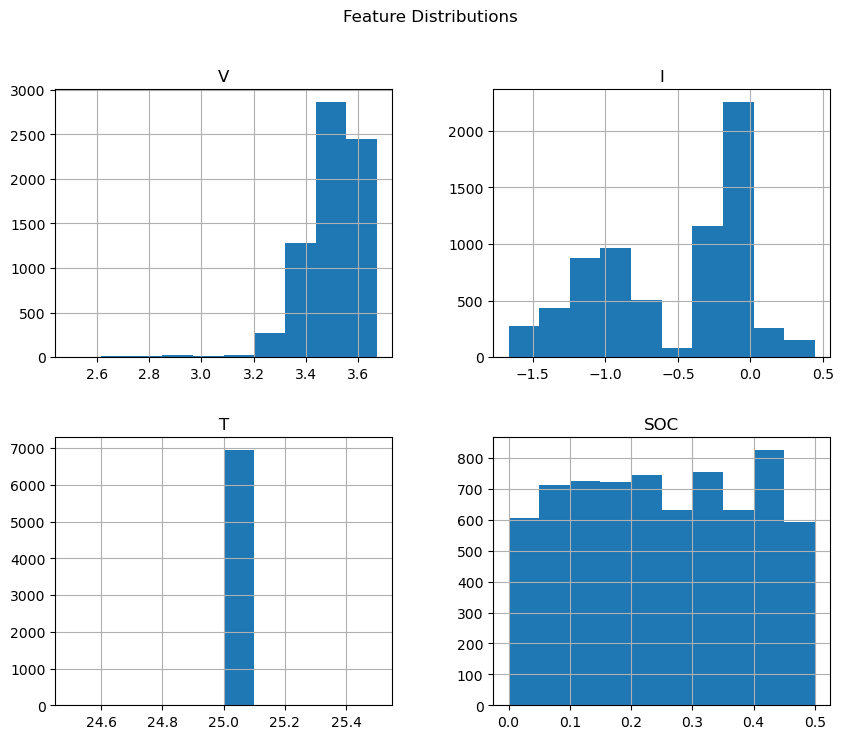

In [7]:
import matplotlib.pyplot as plt

df[['V','I','T','SOC']].hist(figsize=(10,8))

plt.suptitle("Feature Distributions")
plt.show()

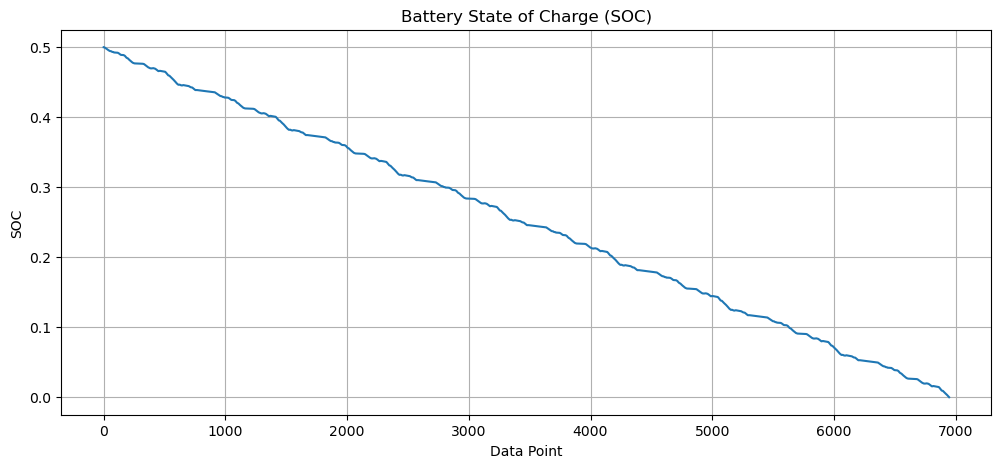

In [8]:
plt.figure(figsize=(12,5))

plt.plot(df['SOC'])

plt.title("Battery State of Charge (SOC)")
plt.xlabel("Data Point")
plt.ylabel("SOC")

plt.grid(True)

plt.show()

### SOC Behaviour Analysis

The SOC values exhibit a gradual decrease over time, reflecting battery discharge behaviour. This trend confirms the sequential nature of the dataset and justifies the use of recurrent neural networks such as GRU, which can learn temporal dependencies from historical measurements.

In [9]:
corr = df[['V','I','T','SOC']].corr()

corr

,V,I,T,SOC
V,1.000000,0.456891,NaN,0.772531
I,0.456891,1.000000,NaN,0.006581
T,NaN,NaN,NaN,NaN
SOC,0.772531,0.006581,NaN,1.000000


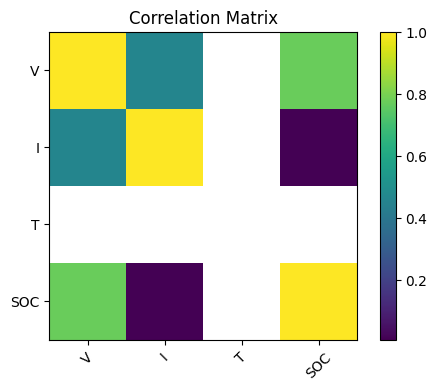

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.imshow(corr)

plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Matrix")

plt.show()

### EDA Conclusion

The exploratory data analysis revealed that the dataset contains 6947 battery measurement records with relevant battery parameters such as Voltage (V), Current (I), Temperature (T), and State of Charge (SOC). No missing values were observed in the selected features, indicating that the dataset is suitable for model development without additional data cleaning.

The voltage measurements vary between 2.50 V and 3.67 V, while the current values range from -1.67 A to 0.44 A, representing different charging and discharging conditions. The SOC values range from 0 to 0.5, showing the battery's charge depletion behavior over time.

Temperature remains constant at 25°C throughout the dataset. Although it provides limited variability for learning, it is retained in the analysis to maintain consistency with the project requirements.

Overall, the dataset exhibits clear temporal patterns in voltage, current, and SOC measurements. Since battery behavior depends on previous operating states, the dataset is well suited for sequence-based deep learning models such as the Gated Recurrent Unit (GRU). Therefore, the next step is to preprocess the data, create sliding windows of historical observations, and train a GRU model for SOC prediction.

# Data Preprocessing and Feature Engineering


Before training the GRU model, the relevant battery parameters are selected and normalized. Since deep learning models perform better when features are on a similar scale, Min-Max normalization is applied to the input variables.

The selected features are:

- Voltage (V)
- Current (I)
- Temperature (T)

The target variable is:

- State of Charge (SOC)

After normalization, sliding windows of 20 timesteps are created to capture the temporal behavior of the battery.

In [10]:
features = ['V', 'I', 'T']
target = 'SOC'

X = df[features]
y = df[target]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (6947, 3)
Target Shape: (6947,)


## Feature Normalization

The selected input features are normalized using Min-Max Scaling. This transforms all feature values into the range [0,1], preventing variables with larger numerical ranges from dominating the learning process.

In [11]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)

print("Scaled Feature Shape:", X_scaled.shape)

Scaled Feature Shape: (6947, 3)


## Sliding Window Generation

Battery behavior depends on historical measurements rather than a single observation. Therefore, a sliding window approach is used.

Each training sample contains:

- 20 previous timesteps
- 3 input features (Voltage, Current, Temperature)

The corresponding SOC value at the next timestep is used as the prediction target.

This transforms the dataset into a sequence learning problem suitable for GRU networks.

In [12]:
window_size = 20

X_seq = []
y_seq = []

for i in range(window_size, len(X_scaled)):
    X_seq.append(X_scaled[i-window_size:i])
    y_seq.append(y.iloc[i])

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

print("Input Shape :", X_seq.shape)
print("Target Shape:", y_seq.shape)

Input Shape : (6927, 20, 3)
Target Shape: (6927,)


# Train-Test Split

The sequential battery dataset is divided into training and testing sets. The training set is used to learn battery behavior patterns, while the testing set is used to evaluate the model's generalization performance on unseen data.

An 80:20 split is used in this project.

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_seq,
    y_seq,
    test_size=0.2,
    random_state=42
)

print("Training Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)

print("Training Labels:", y_train.shape)
print("Testing Labels :", y_test.shape)

Training Shape : (5541, 20, 3)
Testing Shape  : (1386, 20, 3)
Training Labels: (5541,)
Testing Labels : (1386,)


# GRU Model Development

A Gated Recurrent Unit (GRU) neural network is used to model the temporal behavior of battery measurements.

The model receives sequences of 20 timesteps containing Voltage, Current, and Temperature values and learns to predict the corresponding State of Charge (SOC).

GRU networks are particularly suitable for battery applications because they can capture long-term dependencies and sequential patterns in battery behavior.

In [15]:
import tensorflow as tf

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.21.0


## GRU Architecture

The proposed GRU model consists of:

- GRU Layer with 64 units
- Dense Layer with 32 neurons
- Output Layer with 1 neuron

The model takes sequences of battery measurements as input and predicts the corresponding State of Charge (SOC).

In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense

model = Sequential([
    GRU(64, input_shape=(20, 3)),
    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 64)             │        13,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,361 (60.00 KB)

 Trainable params: 15,361 (60.00 KB)

 Non-trainable params: 0 (0.00 B)

#### GRU Model Summary

The developed neural network consists of a GRU layer followed by two dense layers. The GRU layer captures temporal dependencies in battery measurements, while the dense layers learn nonlinear relationships between the extracted features and the target SOC values.

The network contains 15,361 trainable parameters that are optimized during training to minimize prediction error.

In [18]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - loss: 0.0136 - mae: 0.0983 - val_loss: 0.0054 - val_mae: 0.0629
Epoch 2/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0018 - mae: 0.0321 - val_loss: 4.4098e-04 - val_mae: 0.0168
Epoch 3/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 3.1868e-04 - mae: 0.0142 - val_loss: 1.9682e-04 - val_mae: 0.0113
Epoch 4/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 1.6806e-04 - mae: 0.0101 - val_loss: 1.7494e-04 - val_mae: 0.0106
Epoch 5/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 2.8914e-04 - mae: 0.0130 - val_loss: 2.3445e-04 - val_mae: 0.0127
Epoch 6/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 1.1641e-04 - mae: 0.0084 - val_loss: 9.7504e-05 - val_mae: 0.0079
Epoch 7/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 9.8806e-05 - mae: 0.0077 - val_loss: 1.2936e-04 - val_mae: 0.0092
Epoch 8/20
139/139 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 1.2876e-04 - mae: 0.0087 - val_loss: 9.4200e-05 - val_mae: 0.0

In [19]:
history.history.keys()

dict_keys(['loss', 'mae', 'val_loss', 'val_mae'])

#### Model Training Results

The GRU model was trained for 20 epochs using the battery measurement sequences. The training and validation losses decreased consistently throughout training, indicating successful learning of battery temporal behavior.

The final validation MAE was approximately 0.0066, suggesting that the model can accurately estimate battery SOC from historical voltage, current, and temperature measurements.

In [20]:
test_loss, test_mae = model.evaluate(X_test, y_test)

print("Test Loss:", test_loss)
print("Test MAE :", test_mae)

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 6.6599e-05 - mae: 0.0063
Test Loss: 6.659891369054094e-05
Test MAE : 0.006332957651466131


Model Evaluation

The trained GRU model was evaluated on the testing dataset to measure its prediction performance on unseen battery data.

Performance Metrics
Test Loss (MSE): 6.66 × 10⁻⁵
Test MAE: 0.00633

The low Mean Absolute Error indicates that the model can accurately estimate battery SOC from historical voltage, current, and temperature measurements. The close agreement between training, validation, and testing performance suggests good generalization capability.

In [21]:
y_pred = model.predict(X_test)

print(y_pred.shape)

44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
(1386, 1)


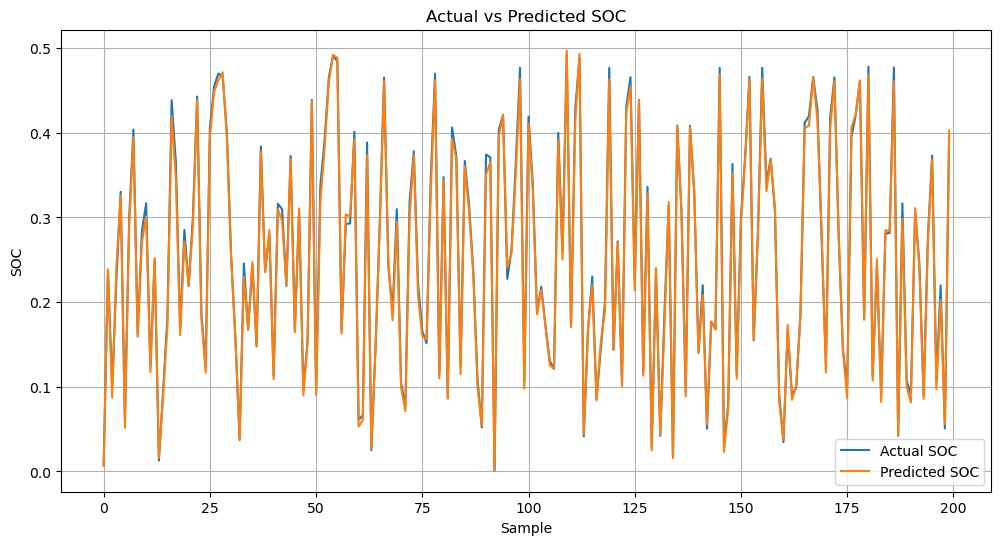

In [22]:
plt.figure(figsize=(12,6))

plt.plot(y_test[:200], label='Actual SOC')
plt.plot(y_pred[:200], label='Predicted SOC')

plt.title('Actual vs Predicted SOC')
plt.xlabel('Sample')
plt.ylabel('SOC')

plt.legend()
plt.grid(True)

plt.show()

### Conclusion

In this project, a GRU-based deep learning model was developed for battery State of Charge (SOC) estimation using the CALCE battery dataset.

The dataset was first analyzed through Exploratory Data Analysis (EDA), followed by feature selection, normalization, and sliding window generation. Voltage, Current, and Temperature measurements were used as input features, while SOC was used as the prediction target.

A GRU neural network was then trained on sequences of historical battery measurements. The model successfully learned the temporal behavior of the battery and achieved strong predictive performance.

Results
Input Shape: (Samples, 20, 3)
GRU Units: 64
Dense Units: 32
Epochs: 20
Test MAE: 0.00633

The Actual vs Predicted SOC plot demonstrated a close match between predicted and actual values, indicating that the GRU model can effectively estimate battery SOC from historical operating data.

Overall, the project confirms that recurrent neural networks such as GRU are suitable for battery management applications where temporal battery behavior plays an important role in SOC estimation.

In [23]:
model.save("gru_soc_model.h5")

print("Model Saved Successfully")

Model Saved Successfully


In [24]:
import os

print(os.getcwd())

C:\Users\shrij
